# Synthetic 2-D experiments — reproduced with the `simplex_tree_classifier` package

This notebook reproduces the two classic 2-D synthetic figures from the original
`in2D` code, but built **entirely on the published package** (`simplex_tree_classifier`):

* **Part A — Multi-polytope fitting (Figure 4).** Two same-class Gaussian clusters on
  a background of the other class. We colour every leaf simplex as
  **green = non-convex**, **yellow = same-side**, **purple = both**, then show the clean
  fit after the redundant/non-convex simplices are merged away.
* **Part B — Non-convex polygon + boundary arrows (panels a/b).** A pentagon with an
  inward notch. We draw the per-simplex decision hyperplane and its normal arrow
  (toward the positive class), both directly on boundary-crossing simplices (Option 1)
  and inferred from the nearest crossing ancestors for the rest (Option 2).

> **Note on the package's `fit`.** `fit()` now *automatically merges back same-side
> subdivisions* (splits the boundary never crosses whose leaves are all one class) — this
> is boundary-preserving and only shrinks the tree. Because the **BEFORE** panel needs the
> *un-pruned* tree to colour the same-side simplices yellow, Part A uses a tiny
> `fit_no_prune` helper that runs the same build/fit steps but skips that automatic merge.
> Everywhere else we use the plain public `fit()`.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.path import Path
from sklearn.svm import LinearSVC

# Make the package importable even if it is not pip-installed in this env.
_pkg_src = os.path.abspath(os.path.join("..", "..", "simplex_tree_package", "src"))
if os.path.isdir(_pkg_src) and _pkg_src not in sys.path:
    sys.path.insert(0, _pkg_src)

import simplex_tree_classifier as stc_pkg
from simplex_tree_classifier import SimplexTreeClassifier
print("simplex_tree_classifier", getattr(stc_pkg, "__version__", "?"), "->", stc_pkg.__file__)

# Colours matching the original figures (blue background / red positive class).
BLUE, RED = "#7d9fe0", "#e07a6b"

def plot_decision(ax, model, res=350, extent=(0.0, 1.0, 0.0, 1.0)):
    """Fill the decision regions of `model` over a grid (red = +1, blue = -1)."""
    x0, x1, y0, y1 = extent
    xx, yy = np.meshgrid(np.linspace(x0, x1, res), np.linspace(y0, y1, res))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    Z = np.asarray(model.predict(grid)).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], colors=[BLUE, RED], alpha=0.85)

def predict_grid(model, xx, yy):
    """Labels on a grid in the tree's OWN coordinates (no normalization), via
    transform -> classifier.predict. This is what the original notebook does
    (`model.transform(grid)` then `classifier.predict`); use it to draw decision
    regions in tree space when the model was fit with normalize=True."""
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    return np.asarray(model.classifier.predict(model.transform(grid))).reshape(xx.shape)

def draw_tree_edges(ax, model, color="k", lw=1.2, alpha=0.7):
    """Draw the triangulation (all leaf-simplex edges)."""
    for verts in model.get_simplex_vertices():
        if len(verts) >= 3:
            closed = list(verts) + [verts[0]]
            bx, by = zip(*closed)
            ax.plot(bx, by, color=color, ls="-", lw=lw, alpha=alpha, zorder=4)

def draw_split_labels(ax, model, fontsize=7):
    """Number the splitting points, as in the original figures."""
    for idx, center in model.tree.get_splitting_points():
        ax.annotate(str(idx), center, fontsize=fontsize, ha="center", va="center",
                    bbox=dict(boxstyle="circle,pad=0.15", facecolor="white",
                              edgecolor="black", alpha=0.85), zorder=10)

def style(ax, title, extent=(0.0, 1.0, 0.0, 1.0)):
    ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal"); ax.set_title(title)

simplex_tree_classifier 0.1.0 -> /home/yasmin/SimplexTreeClassifier/simplex_tree_package/src/simplex_tree_classifier/__init__.py


## Part A — Multi-polytope fitting (Figure 4)

This is an **exact reproduction** of `in2D/to_save_for_paper/2D-two_clusters_2_class copy.ipynb`,
rebuilt on the package. It matches the original point-for-point:

* **same dataset** — `dataset_two_clusters_with_background.npz` (400 red clusters + 800 blue background);
* **same root simplex** — `margin=0` makes the package's enclosing simplex exactly `[(0,0),(2,0),(0,2)]`;
* **same normalization** — `normalize=True` is the original's min-max `_normalize_data`;
* **same model** — `LinearSVC(C=100)`, `subdivision_levels=4`;
* **same drawing** — decision regions in *tree space* via `transform(grid)` (not `predict`), `coolwarm`, extent `[-0.05, 1.5]`.

Two Gaussian clusters that **belong to the same (positive) class** sit on a background of the
negative class; a single linear boundary cannot separate them, so the tree carves out **two red
polytopes**. On the uniform (81-leaf) tree we mark each leaf **Green = non-convex**,
**Yellow = same-side**, **Purple = both**, then remove the union (non-convex ∪ same-side), refit,
and show the cleaned fit — exactly as the original did.

> The BEFORE panel uses `fit_no_prune` (the package's `fit` steps minus the automatic same-side
> merge) so the 81 leaves — including the yellow same-side ones — are still present to colour.

loaded ../tests/datasets/dataset_two_clusters_with_background.npz
two-cluster dataset: 1200 points  (red +1: 400, blue -1: 800)


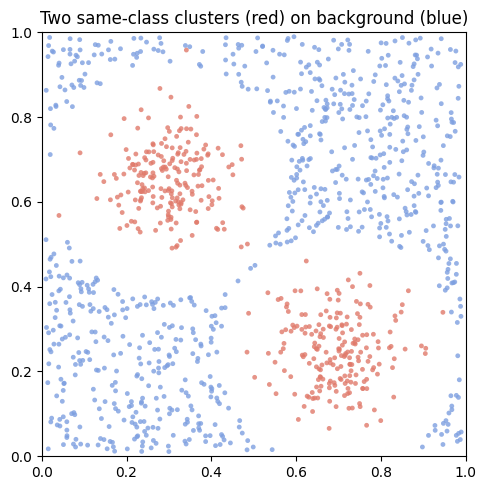

In [2]:
# --- Two same-class clusters + background ------------------------------------
# We use the SAME stored dataset as
# in2D/to_save_for_paper/2D-two_clusters_2_class copy.ipynb, i.e.
# dataset_two_clusters_with_background.npz (400 red clusters + 800 blue background,
# made with generate_two_clusters.py, same_class=True). If the file is missing we
# regenerate an *equivalent* set (note: the legacy generator used np.random.seed,
# so a regenerated set is only statistically equivalent, not identical).
def generate_two_clusters(n_cluster=200, n_background=800, margin=0.25, seed=42):
    np.random.seed(seed)                       # legacy RNG, matching the original script
    r = 0.08
    c1x, c1y, c2x, c2y = 0.25, 0.65, 0.75, 0.35
    off = margin * 0.5
    c1x -= off * 0.5; c1y += off * 0.3; c2x += off * 0.5; c2y -= off * 0.3
    cl1 = np.random.normal([c1x, c1y], r, (n_cluster, 2))
    cl2 = np.random.normal([c2x, c2y], r, (n_cluster, 2))
    excl = r * 3 + margin * 0.3
    bg, att = [], 0
    while len(bg) < n_background and att < n_background * 20:
        x, yv = np.random.uniform(0.05, 0.95), np.random.uniform(0.05, 0.95)
        if np.hypot(x - c1x, yv - c1y) > excl and np.hypot(x - c2x, yv - c2y) > excl:
            bg.append([x, yv])
        att += 1
    bg = np.array(bg)
    X = np.vstack([cl1, cl2, bg])
    y = np.concatenate([np.ones(n_cluster), np.ones(n_cluster), -np.ones(len(bg))])
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

_ds = os.path.join("..", "tests", "datasets", "dataset_two_clusters_with_background.npz")
if os.path.exists(_ds):
    _d = np.load(_ds); Xc, yc = _d["X"], _d["y"]
    print(f"loaded {_ds}")
else:
    Xc, yc = generate_two_clusters()
    print("stored dataset not found -> regenerated an equivalent set")

Xc = np.clip(Xc, 0.0, 1.0)                     # stay inside the unit square (normalize=False)
print(f"two-cluster dataset: {Xc.shape[0]} points  "
      f"(red +1: {(yc==1).sum()}, blue -1: {(yc==-1).sum()})")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Xc[:, 0], Xc[:, 1], c=[RED if t == 1 else BLUE for t in yc],
           s=12, edgecolors="none", alpha=0.8)
style(ax, "Two same-class clusters (red) on background (blue)")
plt.tight_layout(); plt.show()

In [3]:
# fit_no_prune reruns exactly what SimplexTreeClassifier.fit does, minus the
# automatic same-side merge, so the BEFORE picture keeps all 81 leaves (this
# matches the original's fit, which did not auto-merge same-side).
def fit_no_prune(clf, X, y):
    X = np.asarray(X, float); y = np.asarray(y)
    if not clf._normalize_enabled():
        clf._ensure_in_unit_cube(X)
    clf._X_fit, clf._y_fit = X, y
    clf._fit_scaler(X)
    Xn = clf._apply_scaler(X)
    clf._X_train_norm, clf._y_train = Xn, y
    clf._ensure_tree(X.shape[1])
    clf._fit_estimator(clf.transform(Xn), y)
    clf._finalize_fit()          # detects same-side, does NOT remove
    return clf

def refit_only(clf):
    """Rebuild lookups and refit the classifier on the (pruned) tree WITHOUT the
    automatic same-side merge -- the package equivalent of the original's
    `model._build_node_lookup(); model.fit(X, y)` after a manual removal."""
    clf._mark_dirty(); clf._sync()
    clf._fit_estimator(clf.transform(clf._X_train_norm), clf._y_train)
    clf._finalize_fit()
    return clf

SUBDIV  = 4        # uniform subdivision levels
C_SVM   = 100.0
EPSILON = 0.30     # boundary test-point placement for the convexity check

# margin=0 -> enclosing simplex == the original root triangle [(0,0),(2,0),(0,2)];
# normalize=True -> the original min-max normalization.
def new_model():
    return SimplexTreeClassifier(classifier=LinearSVC(C=C_SVM, max_iter=20000),
                                 subdivision_levels=SUBDIV, normalize=True, margin=0.0)

before = fit_no_prune(new_model(), Xc, yc)

# Grid in the tree's own coordinates (the [(0,0),(2,0),(0,2)] triangle), exactly
# like the original: x, y in [-0.05, 1.5].
EXT = (-0.05, 1.5)
xx, yy = np.meshgrid(np.linspace(*EXT, 400), np.linspace(*EXT, 400))

nonconvex_keys = set(before.find_nonconvex_leaves(criterion="convexity_sign",
                                                  epsilon=EPSILON).keys())
same_side_keys = before.find_same_side_simplices()
combined_keys  = nonconvex_keys | same_side_keys

print(f"Model built with {len(before.leaf_simplexes)} leaf simplices")
print(f"  non-convex : {len(nonconvex_keys)}")
print(f"  same-side  : {len(same_side_keys)}")
print(f"  combined   : {len(combined_keys)}")

Model built with 81 leaf simplices
  non-convex : 23
  same-side  : 36
  combined   : 59


/home/yasmin/SimplexTreeClassifier/myvenv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


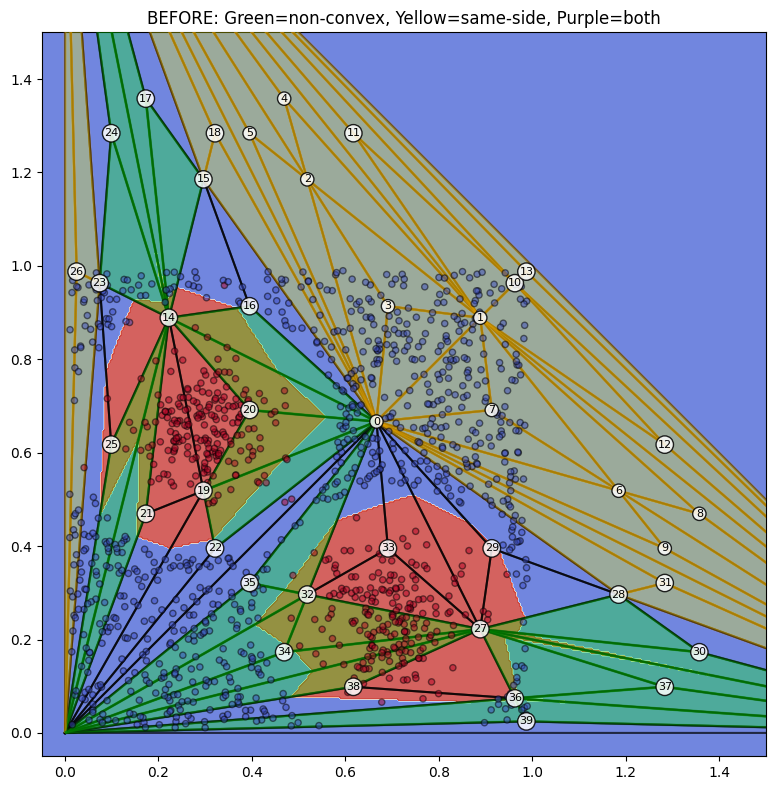

In [4]:
# --- BEFORE panel: colour-coded non-convex / same-side / both ----------------
fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, predict_grid(before, xx, yy), cmap=plt.cm.coolwarm, alpha=0.8)
draw_tree_edges(ax, before, lw=1.5, alpha=0.7)

for leaf in before.tree.get_leaves():
    key = frozenset(leaf.vertex_indices)
    is_nc, is_ss = key in nonconvex_keys, key in same_side_keys
    if is_nc and is_ss:
        color, edge = "purple", "darkviolet"
    elif is_nc:
        color, edge = "lime", "green"
    elif is_ss:
        color, edge = "yellow", "orange"
    else:
        continue
    ax.add_patch(patches.Polygon(np.array(leaf.vertices), closed=True, facecolor=color,
                                 alpha=0.3, edgecolor=edge, linewidth=2, zorder=6))

draw_split_labels(ax, before, fontsize=8)
ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap=plt.cm.coolwarm, s=20, edgecolors="k", alpha=0.5, zorder=8)
ax.set_xlim(*EXT); ax.set_ylim(*EXT); ax.set_aspect("equal")
ax.set_title("BEFORE: Green=non-convex, Yellow=same-side, Purple=both")
plt.tight_layout(); plt.show()

In [5]:
# --- AFTER: remove the union (non-convex U same-side) once, then refit --------
# This mirrors the original notebook exactly: build the same 81-leaf tree, detect
# non-convex + same-side, collapse their union with remove_by_leaf_key, and refit.
after = fit_no_prune(new_model(), Xc, yc)
nc = set(after.find_nonconvex_leaves(criterion="convexity_sign", epsilon=EPSILON).keys())
ss = after.find_same_side_simplices()
combined = nc | ss
removed = sum(1 for key in combined if after.tree.remove_by_leaf_key(key))
refit_only(after)
leaves_final = len(after.leaf_simplexes)

print(f"leaves before removal : {len(before.leaf_simplexes)}")
print(f"removed (non-convex U same-side) : {removed}")
print(f"leaves after removal  : {leaves_final}")

leaves before removal : 81
removed (non-convex U same-side) : 25
leaves after removal  : 31


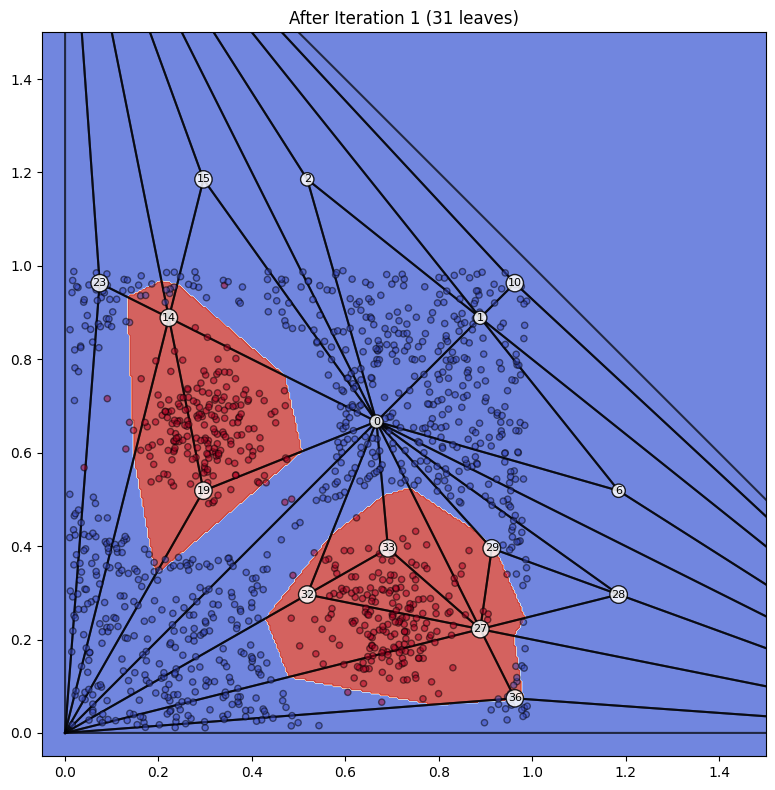

In [6]:
# --- AFTER panel: the clean two-polytope fit --------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, predict_grid(after, xx, yy), cmap=plt.cm.coolwarm, alpha=0.8)
draw_tree_edges(ax, after, lw=1.5, alpha=0.7)
draw_split_labels(ax, after, fontsize=8)
ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap=plt.cm.coolwarm, s=20, edgecolors="k", alpha=0.5, zorder=8)
ax.set_xlim(*EXT); ax.set_ylim(*EXT); ax.set_aspect("equal")
ax.set_title(f"After Iteration 1 ({leaves_final} leaves)")
plt.tight_layout(); plt.show()

## Part B — Non-convex polygon + boundary arrows (three stages)

**Exact reproduction** of `in2D/to_save_for_paper/explained_polygon_2_options_notch.ipynb`,
rebuilt on the package with the same settings:

* **same dataset** — the stored `dataset_polygon_notch.npz` (800 pts, 400 +1 / 400 −1);
* **same root simplex** — `margin=0` ⇒ enclosing simplex `[(0,0),(2,0),(0,2)]`;
* **same normalization / model** — `normalize=True`, `LinearSVC(C=10000)`, `subdivision_levels=4`, `EPSILON=0.30`;
* **same drawing** — tree-space `transform(grid)`, `coolwarm`, extent `[-0.05, 1.5]`.

Each boundary-crossing leaf carries a local hyperplane; its **normal points toward the
positive class**. Non-crossing leaves *infer* a direction by averaging the normals of the
nearest crossing leaves found by walking up the tree (dark-blue arrows).

We show the classic **three stages**:

1. **Arrows on the raw tree** — inside the concave notch, the non-convex / same-side leaves
   make some arrows point the **wrong** way.
2. **Removal** — colour the non-convex (green) + same-side (yellow) leaves and merge them
   away (remove their union, refit, and **repeat until no non-convex leaves remain** — a
   single pass can leave or expose new bends, so several passes are needed).
3. **Arrows on the cleaned tree** — the same arrows now point **correctly**.

All arrow geometry (gradient + edge crossings) is computed from the fitted linear weights
via the package's public API (`get_weights_and_intercept`, `tree.get_leaves`, node
`parent`/`children`).

loaded ../tests/datasets/dataset_polygon_notch.npz
notch dataset: 800 points  (red +1: 400, blue -1: 400)


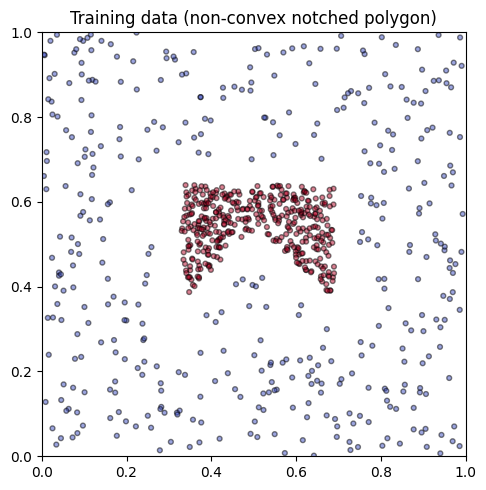

In [7]:
# --- Non-convex (notched) polygon dataset -----------------------------------
# Use the SAME stored dataset as the original notebook: dataset_polygon_notch.npz
# (800 points in the unit square, 400 +1 inside the notched polygon / 400 -1 outside).
# The inline generator is kept only as a fallback if the file is missing.
def generate_notch_fallback(n_samples=50000, n_per_class=400, seed=42):
    verts = np.array([[0.3, 0.67], [0.3, 0.3], [0.51, 0.5], [0.72, 0.3], [0.72, 0.67]])
    path, margin = Path(verts), 0.06
    rng = np.random.default_rng(seed)
    pts = rng.uniform(0, 1, (n_samples, 2))
    inside   = path.contains_points(pts)
    shrunk   = path.contains_points(pts, radius=-margin)
    expanded = path.contains_points(pts, radius=margin)
    lab = np.where(inside, 1.0, -1.0); lab[expanded & ~shrunk] = 0.0
    keep = lab != 0.0; pts, lab = pts[keep], lab[keep]
    ins = np.where(lab == 1.0)[0]; out = np.where(lab == -1.0)[0]
    n = min(len(ins), len(out), n_per_class)
    sel = np.concatenate([ins[:n], out[:n]]); rng.shuffle(sel)
    return pts[sel], lab[sel]

_dp = os.path.join("..", "tests", "datasets", "dataset_polygon_notch.npz")
if os.path.exists(_dp):
    _d = np.load(_dp); Xp, yp = _d["X"], _d["y"]
    print(f"loaded {_dp}")
else:
    Xp, yp = generate_notch_fallback()
    print("stored notch dataset not found -> regenerated an equivalent set")
print(f"notch dataset: {Xp.shape[0]} points  (red +1: {(yp==1).sum()}, blue -1: {(yp==-1).sum()})")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Xp[:, 0], Xp[:, 1], c=yp, cmap=plt.cm.coolwarm, s=12, edgecolors="k", alpha=0.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_title("Training data (non-convex notched polygon)")
plt.tight_layout(); plt.show()

In [8]:
# --- Build the FULL (un-pruned) model, matching the original exactly ---------
# margin=0 -> root triangle [(0,0),(2,0),(0,2)]; normalize=True -> the original
# min-max normalization; subdivision_levels=4, LinearSVC(C=10000). fit_no_prune
# keeps every leaf so stage 1 can draw arrows on the raw tree.
SUBDIV_P = 4
def new_model_p():
    return SimplexTreeClassifier(classifier=LinearSVC(C=10000, max_iter=50000),
                                 subdivision_levels=SUBDIV_P, normalize=True, margin=0.0)

model_p = fit_no_prune(new_model_p(), Xp, yp)
print(f"notch model: {len(model_p.leaf_simplexes)} leaves (uniform, pre-prune)")

# --- Arrow drawing (Option 2: direct dark-red + inferred dark-blue) ----------
# Self-contained: re-reads the weights each call, so it renders correctly both
# before and after the removal/refit. Uses only public API + node parent/children.
def draw_arrows(ax, model, arrow=0.08):
    w, b = model.get_weights_and_intercept()

    def dvals(leaf):
        return np.array([w[i] + b for i in leaf.vertex_indices], float)

    def crosses(leaf):
        d = dvals(leaf)
        return bool((d > 0).any() and (d < 0).any())

    def gradient(leaf):
        """Cartesian gradient (a, b) of the linear decision fn in this 2-simplex."""
        V = np.array(leaf.get_vertices_as_tuples(), float); d = dvals(leaf)
        M = np.array([V[1] - V[0], V[2] - V[0]]); rhs = np.array([d[1] - d[0], d[2] - d[0]])
        try:
            return np.linalg.solve(M, rhs)
        except np.linalg.LinAlgError:
            return None

    def edge_crossings(leaf):
        V = np.array(leaf.get_vertices_as_tuples(), float); d = dvals(leaf)
        n = len(V); pts = []
        for i in range(n):
            j = (i + 1) % n; di, dj = d[i], d[j]
            if (di < 0) != (dj < 0) and di != dj:
                t = di / (di - dj); pts.append(V[i] + t * (V[j] - V[i]))
        return pts

    def descendants(node):                       # leaf test = no children (public)
        if not node.children:
            yield node
        else:
            for c in node.children:
                yield from descendants(c)

    def nearest_gradients(leaf):
        """Walk up the tree; gradients of crossing leaves at the first ancestor
        level whose sibling subtrees contain a boundary crossing."""
        cur = leaf
        while cur.parent is not None:
            found = []
            for sib in cur.parent.children:
                if sib is cur:
                    continue
                for desc in descendants(sib):
                    if crosses(desc):
                        g = gradient(desc)
                        if g is not None:
                            found.append(g)
            if found:
                return found
            cur = cur.parent
        return []

    direct = inferred = skipped = 0
    for leaf in model.tree.get_leaves():
        verts = np.array(leaf.get_vertices_as_tuples(), float)
        if len(verts) < 3:
            continue
        centroid = verts.mean(axis=0)
        if crosses(leaf):
            g = gradient(leaf)
            if g is None or np.hypot(*g) < 1e-12:
                skipped += 1; continue
            pts = edge_crossings(leaf)
            if len(pts) >= 2:
                p0, p1 = pts[0], pts[1]
                ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="black", lw=2.0, zorder=11)
                origin = 0.5 * (p0 + p1)
            else:
                origin = centroid
            nrm = g / np.hypot(*g)               # normal toward the positive class
            ax.annotate("", xy=tuple(origin + nrm * arrow), xytext=tuple(origin),
                        arrowprops=dict(arrowstyle="->", color="darkred", lw=2, mutation_scale=15),
                        zorder=12)
            direct += 1
        else:
            grads = nearest_gradients(leaf)
            normals = [g / np.hypot(*g) for g in grads if np.hypot(*g) > 1e-12]
            if not normals:
                skipped += 1; continue
            avg = np.mean(normals, axis=0)
            if np.linalg.norm(avg) < 1e-12:
                skipped += 1; continue
            avg /= np.linalg.norm(avg)
            ax.annotate("", xy=tuple(centroid + avg * arrow), xytext=tuple(centroid),
                        arrowprops=dict(arrowstyle="->", color="darkblue", lw=2, mutation_scale=13),
                        zorder=12)
            inferred += 1
    return direct, inferred, skipped

notch model: 81 leaves (uniform, pre-prune)


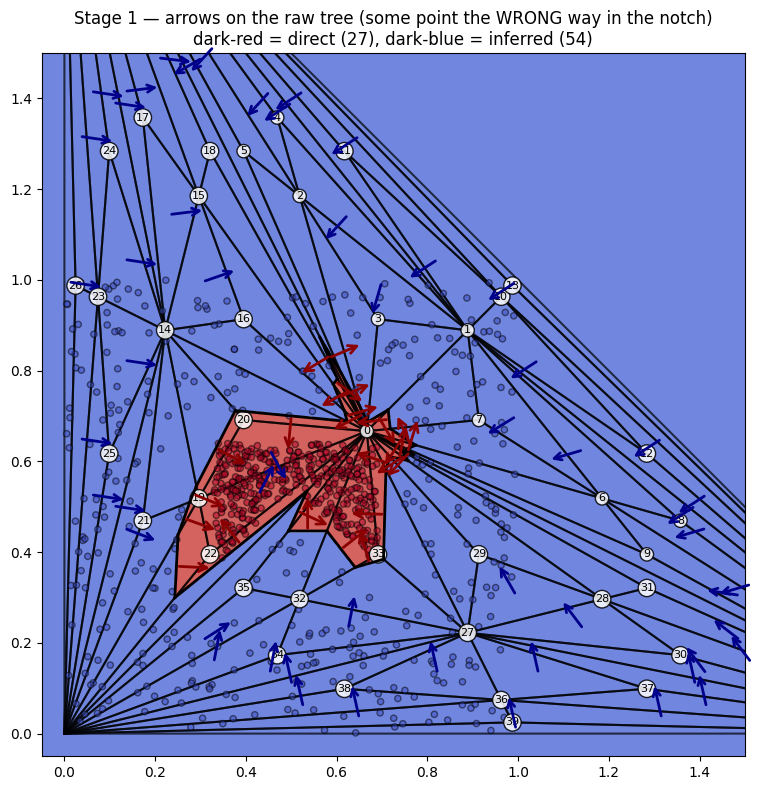

In [9]:
# --- STAGE 1: arrows on the RAW tree -- wrong inside the notch ----------------
fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, predict_grid(model_p, xx, yy), cmap=plt.cm.coolwarm, alpha=0.8)
draw_tree_edges(ax, model_p, lw=1.5, alpha=0.7)
d1, i1, s1 = draw_arrows(ax, model_p)
draw_split_labels(ax, model_p, fontsize=8)
ax.scatter(Xp[:, 0], Xp[:, 1], c=yp, cmap=plt.cm.coolwarm, s=20, edgecolors="k", alpha=0.5, zorder=8)
ax.set_xlim(*EXT); ax.set_ylim(*EXT); ax.set_aspect("equal")
ax.set_title(f"Stage 1 — arrows on the raw tree (some point the WRONG way in the notch)\n"
             f"dark-red = direct ({d1}), dark-blue = inferred ({i1})")
plt.tight_layout(); plt.show()

non-convex: 20   same-side: 42   combined: 62
leaves before removal: 81


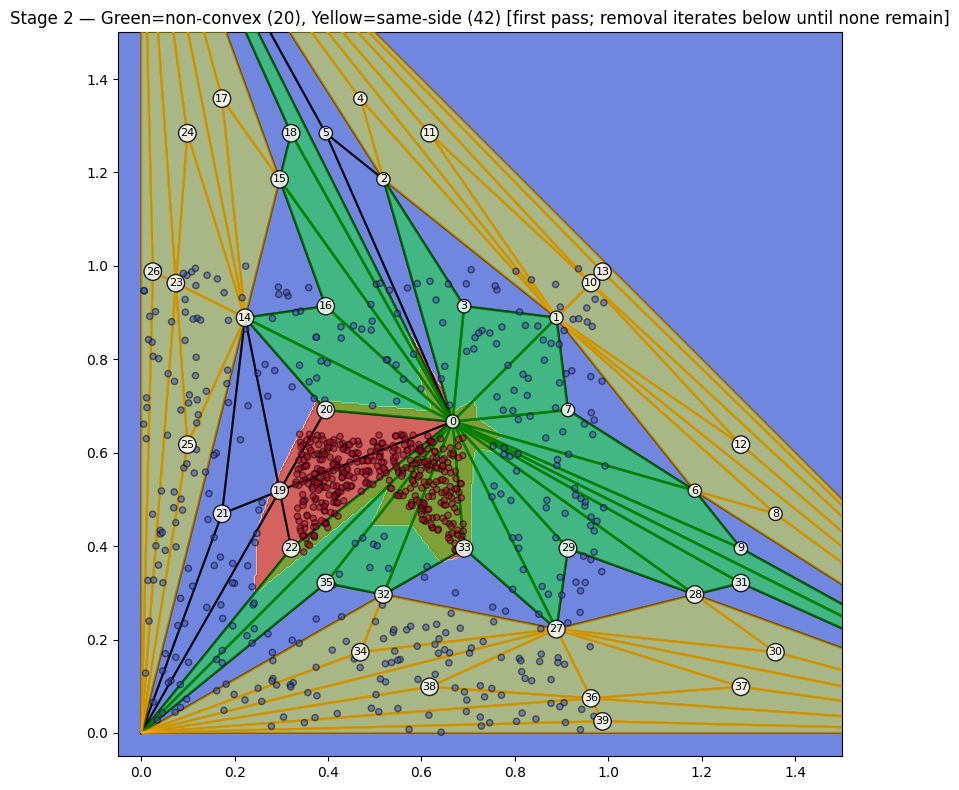

pass 1: non-convex 20, same-side 42 -> removed 25, 31 leaves remain
pass 2: non-convex 13, same-side 9 -> removed 11, 9 leaves remain
pass 3: nothing left to remove -> converged
non-convex leaves remaining: 0   final leaves: 9


In [10]:
# --- STAGE 2: colour the non-convex (green) + same-side (yellow) leaves, remove
#             their union, and refit -- exactly as the original notebook did ----
nc_p = set(model_p.find_nonconvex_leaves(criterion="convexity_sign", epsilon=EPSILON).keys())
ss_p = model_p.find_same_side_simplices()
combined_p = nc_p | ss_p
print(f"non-convex: {len(nc_p)}   same-side: {len(ss_p)}   combined: {len(combined_p)}")
print(f"leaves before removal: {len(model_p.leaf_simplexes)}")

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, predict_grid(model_p, xx, yy), cmap=plt.cm.coolwarm, alpha=0.8)
draw_tree_edges(ax, model_p, lw=1.5, alpha=0.7)
for leaf in model_p.tree.get_leaves():
    key = frozenset(leaf.vertex_indices)
    is_nc, is_ss = key in nc_p, key in ss_p
    if is_nc and is_ss:
        color, edge = "purple", "darkviolet"
    elif is_nc:
        color, edge = "lime", "green"
    elif is_ss:
        color, edge = "yellow", "orange"
    else:
        continue
    ax.add_patch(patches.Polygon(np.array(leaf.vertices), closed=True, facecolor=color,
                                 alpha=0.4, edgecolor=edge, linewidth=2, zorder=6))
draw_split_labels(ax, model_p, fontsize=8)
ax.scatter(Xp[:, 0], Xp[:, 1], c=yp, cmap=plt.cm.coolwarm, s=20, edgecolors="k", alpha=0.5, zorder=8)
ax.set_xlim(*EXT); ax.set_ylim(*EXT); ax.set_aspect("equal")
ax.set_title(f"Stage 2 — Green=non-convex ({len(nc_p)}), Yellow=same-side ({len(ss_p)}) "
             f"[first pass; removal iterates below until none remain]")
plt.tight_layout(); plt.show()

# Remove the union and refit, then REPEAT: a single pass can leave (or newly
# expose) non-convex bends and same-side splits, so we iterate until none are
# left. This is why the original ran several removal passes.
for _pass in range(1, 11):
    nc = set(model_p.find_nonconvex_leaves(criterion="convexity_sign", epsilon=EPSILON).keys())
    ss = model_p.find_same_side_simplices()
    combined = nc | ss
    if not combined:
        print(f"pass {_pass}: nothing left to remove -> converged")
        break
    removed = sum(1 for key in combined if model_p.tree.remove_by_leaf_key(key))
    refit_only(model_p)
    print(f"pass {_pass}: non-convex {len(nc)}, same-side {len(ss)} "
          f"-> removed {removed}, {len(model_p.leaf_simplexes)} leaves remain")

# confirm the tree is now free of non-convex leaves
_nc_left = len(model_p.find_nonconvex_leaves(criterion="convexity_sign", epsilon=EPSILON))
print(f"non-convex leaves remaining: {_nc_left}   final leaves: {len(model_p.leaf_simplexes)}")

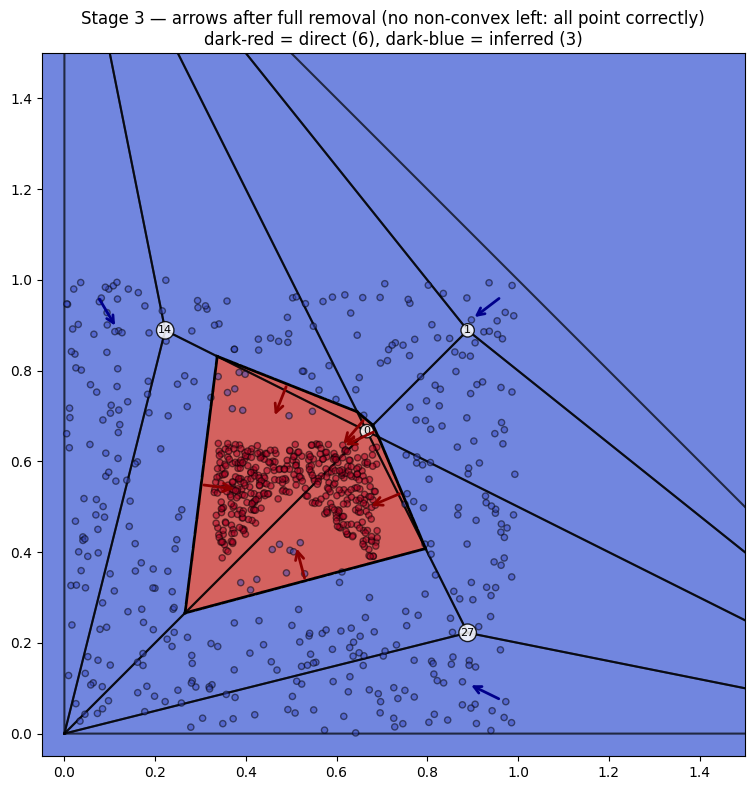

In [11]:
# --- STAGE 3: arrows on the CLEANED tree -- now they point correctly ----------
fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, predict_grid(model_p, xx, yy), cmap=plt.cm.coolwarm, alpha=0.8)
draw_tree_edges(ax, model_p, lw=1.5, alpha=0.7)
d3, i3, s3 = draw_arrows(ax, model_p)
draw_split_labels(ax, model_p, fontsize=8)
ax.scatter(Xp[:, 0], Xp[:, 1], c=yp, cmap=plt.cm.coolwarm, s=20, edgecolors="k", alpha=0.5, zorder=8)
ax.set_xlim(*EXT); ax.set_ylim(*EXT); ax.set_aspect("equal")
ax.set_title(f"Stage 3 — arrows after full removal (no non-convex left: all point correctly)\n"
             f"dark-red = direct ({d3}), dark-blue = inferred ({i3})")
plt.tight_layout(); plt.show()

### Takeaways

* The simplex tree fits **non-convex / disconnected** positive regions that a single
  linear boundary cannot (two red polytopes in Part A, the notched polygon in Part B).
* Every boundary-crossing simplex carries a local hyperplane whose **normal points toward
  the positive class**; leaves without their own crossing borrow the averaged direction of
  the nearest crossing simplices found by walking up the tree (dark-blue inferred arrows).
* The **three stages** make the point: on the raw tree the non-convex / same-side leaves in
  the concave notch make some arrows point the **wrong** way (Stage 1); removing the union
  of non-convex (green) + same-side (yellow) leaves and refitting cleans the boundary
  (Stage 2); the same arrows then point **correctly** outward (Stage 3).